<a href="https://colab.research.google.com/github/pondpatipatpankaew/GE338/blob/main/LAB/Lab3/lab3_classification_6606520168_%E0%B8%9B%E0%B8%8F%E0%B8%B4%E0%B8%9E%E0%B8%B1%E0%B8%92%E0%B8%99%E0%B9%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# 1) Install & Import
# =========================
!pip install rasterio scikit-learn seaborn -q

In [2]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score
from sklearn.cluster import KMeans


In [3]:
# =========================
# 2) Mount Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# =========================
# 3) OUTPUT FOLDER
# =========================
out_dir = '/content/drive/MyDrive/GE338/OUTPUT'
os.makedirs(out_dir, exist_ok=True)

In [5]:
# =========================
# 4) Load CSV
# =========================
c100point_path = '/content/drive/MyDrive/GEE_Export/S2_Training_4Class.csv'
c300point_path = '/content/drive/MyDrive/GEE_Export/S2_Training_4Class300.csv'

df1 = pd.read_csv(c100point_path)
df2 = pd.read_csv(c300point_path)

In [6]:
# =========================
# 5) Features
# =========================
features = ['B2','B3','B4','B8','B11','B12','NDVI','NDWI','NDBI','NDMI']

X1 = df1[features].values.astype('float32')
y1 = df1['class'].values

X2 = df2[features].values.astype('float32')
y2 = df2['class'].values

X_combined = np.vstack([X1, X2])
y_combined = np.hstack([y1, y2])

In [7]:
# =========================
# 6) Train Function
# =========================
def train_rf(X, y, title=""):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)

    print(f"\n=== {title} ===")
    print("Accuracy:", acc)
    print("Kappa:", kappa)
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=labels))

    return rf, acc, y_test, y_pred


In [8]:
# =========================
# 7) Train Compare
# =========================
labels = ['Urban','Water','Agriculture','Forest']

rf_1, acc_1, y_test1, y_pred1 = train_rf(X1, y1, "RF 100 Points")
rf_2, acc_2, y_test2, y_pred2 = train_rf(X_combined, y_combined, "RF Combined 300 Points")

print("\n🔥 Improvement in Accuracy:", round(acc_2 - acc_1, 4))
print("🔥 Improvement in Kappa:", round(cohen_kappa_score(y_test2, y_pred2) - cohen_kappa_score(y_test1, y_pred1), 4))



=== RF 100 Points ===
Accuracy: 1.0
Kappa: 1.0
Classification Report:
               precision    recall  f1-score   support

       Urban       1.00      1.00      1.00        33
       Water       1.00      1.00      1.00        29
 Agriculture       1.00      1.00      1.00        28
      Forest       1.00      1.00      1.00        30

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120


=== RF Combined 300 Points ===
Accuracy: 1.0
Kappa: 1.0
Classification Report:
               precision    recall  f1-score   support

       Urban       1.00      1.00      1.00        79
       Water       1.00      1.00      1.00        79
 Agriculture       1.00      1.00      1.00       107
      Forest       1.00      1.00      1.00        95

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.0

In [9]:
# =========================
# 8) Load Raster
# =========================
tif_path = '/content/drive/MyDrive/GE338/LAB3/S2/S2Lab3allbands-0000000000-0000000000.tif'

with rasterio.open(tif_path) as src:
    B2 = src.read(2).astype('float32')
    B3 = src.read(3).astype('float32')
    B4 = src.read(4).astype('float32')
    B8 = src.read(8).astype('float32')
    B11 = src.read(11).astype('float32')
    B12 = src.read(12).astype('float32')


In [10]:
# =========================
# 9) Indices
# =========================
ndvi = (B8 - B4) / (B8 + B4 + 1e-6)
ndwi = (B3 - B8) / (B3 + B8 + 1e-6)
ndbi = (B11 - B8) / (B11 + B8 + 1e-6)
ndmi = (B8 - B11) / (B8 + B11 + 1e-6)

stack = np.stack([B2,B3,B4,B8,B11,B12,ndvi,ndwi,ndbi,ndmi], axis=-1)
X_full = stack.reshape(-1, stack.shape[-1])

In [11]:
# =========================
# 10) Predict Maps
# =========================
map1 = rf_1.predict(X_full).reshape(stack.shape[:2])
map2 = rf_2.predict(X_full).reshape(stack.shape[:2])


In [12]:
# =========================
# 11) Difference Map
# =========================
diff = map1 != map2
diff_percent = np.mean(diff)*100
print("Change % between RF maps:", round(diff_percent,2))

Change % between RF maps: 10.53


In [13]:
# =========================
# 12) Feature Importance
# =========================
importance = rf_2.feature_importances_

In [14]:
# =========================
# 13) Confidence Map
# =========================
probs = rf_2.predict_proba(X_full)
conf = np.max(probs, axis=1).reshape(stack.shape[:2])

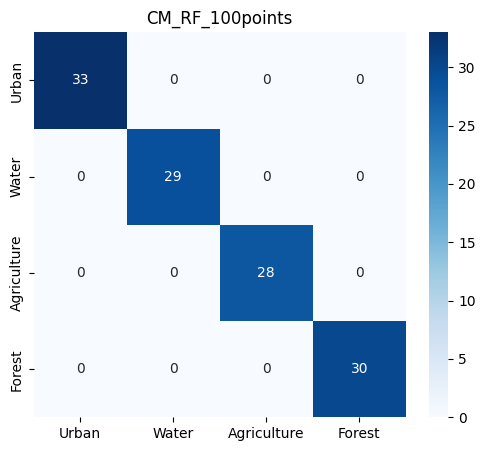

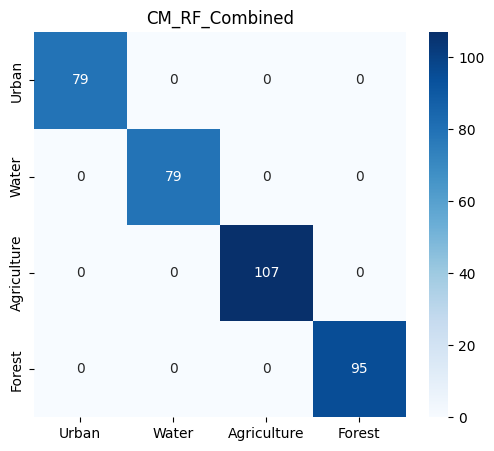

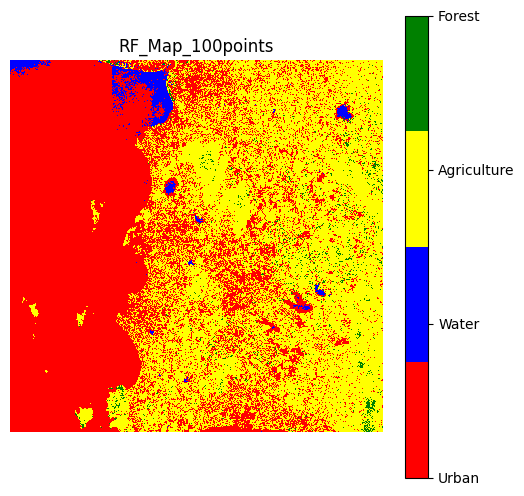

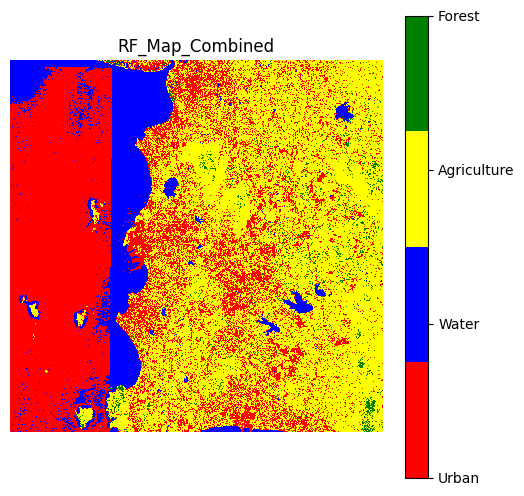

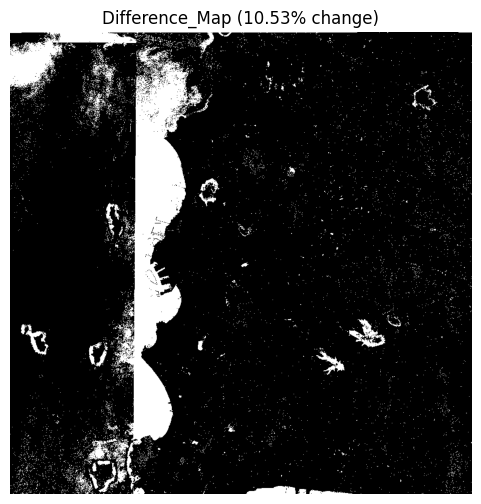

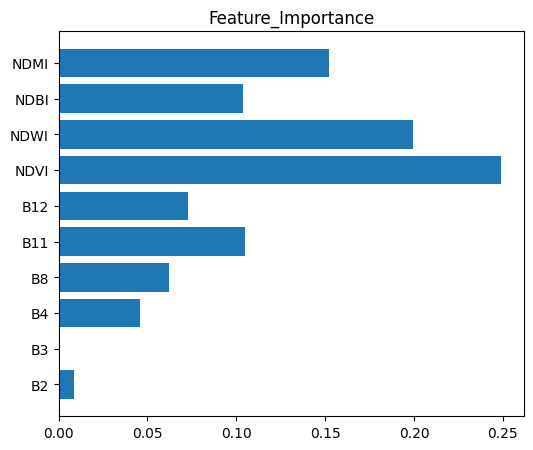

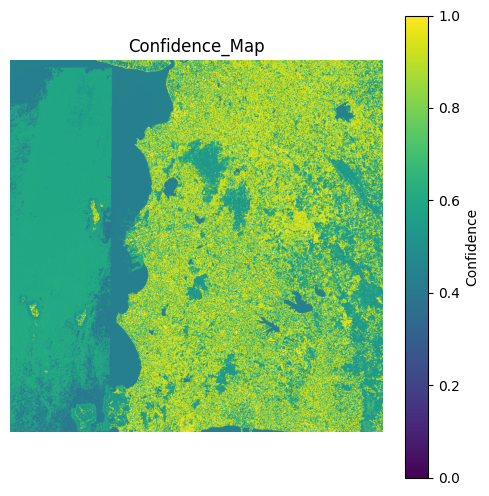

✅ All maps and plots exported as JPEG to: /content/drive/MyDrive/GE338/OUTPUT


In [19]:
# =========================
# 14) Plot + Export All Maps (JPEG, Fixed)
# =========================
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['red','blue','yellow','green'])

# --- Function: Predicted / Class Maps ---
def show_and_save_map_jpeg(data, name, cmap=cmap, labels=labels, vmin=0, vmax=3):
    data_plot = np.nan_to_num(data)

    # โชว์แบบลด resolution
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(data_plot[::5, ::5], cmap=cmap, interpolation='nearest', vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(im, ax=ax, ticks=[0,1,2,3])
    cbar.ax.set_yticklabels(labels)
    ax.set_title(name)
    ax.axis('off')
    plt.show()

    # เซฟ JPEG ไฟล์
    fig.savefig(f"{out_dir}/{name}.jpg", dpi=150, bbox_inches='tight')
    plt.close(fig)

# --- Function: Confusion Matrix ---
def show_and_save_cm_jpeg(y_test, y_pred, name):
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name)
    plt.show()

    fig.savefig(f"{out_dir}/{name}.jpg", dpi=150, bbox_inches='tight')
    plt.close(fig)

# --- Function: Difference Map ---
def show_and_save_diff_jpeg(diff, percent, name):
    diff_plot = diff.astype(float)
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(diff_plot[::5, ::5], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"{name} ({round(percent,2)}% change)")
    ax.axis('off')
    plt.show()
    fig.savefig(f"{out_dir}/{name}.jpg", dpi=150, bbox_inches='tight')
    plt.close(fig)

# --- Function: Feature Importance ---
def show_and_save_feature_importance_jpeg(features, importance, name):
    fig, ax = plt.subplots(figsize=(6,5))
    ax.barh(features, importance)
    ax.set_title(name)
    plt.show()
    fig.savefig(f"{out_dir}/{name}.jpg", dpi=150, bbox_inches='tight')
    plt.close(fig)

# --- Function: Confidence Map ---
def show_and_save_confidence_jpeg(conf, name):
    conf_plot = np.nan_to_num(conf)
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(conf_plot[::5, ::5], cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Confidence')
    ax.set_title(name)
    ax.axis('off')
    plt.show()
    fig.savefig(f"{out_dir}/{name}.jpg", dpi=150, bbox_inches='tight')
    plt.close(fig)

# =========================
# Export Everything
# =========================

# Confusion Matrix
show_and_save_cm_jpeg(y_test1, y_pred1, "CM_RF_100points")
show_and_save_cm_jpeg(y_test2, y_pred2, "CM_RF_Combined")

# Predicted Maps
show_and_save_map_jpeg(map1, "RF_Map_100points")
show_and_save_map_jpeg(map2, "RF_Map_Combined")

# Difference Map
show_and_save_diff_jpeg(diff, diff_percent, "Difference_Map")

# Feature Importance
show_and_save_feature_importance_jpeg(features, importance, "Feature_Importance")

# Confidence Map
show_and_save_confidence_jpeg(conf, "Confidence_Map")

print("✅ All maps and plots exported as JPEG to:", out_dir)